In [1]:
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
iris.data, iris.target, test_size=0.2, random_state=42)
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred, target_names=iris.target_names))

Accuracy: 1.0
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [1]:
from sklearn.datasets import load_iris
import pandas as pd
# Load the Iris dataset
iris = load_iris()

# Convert to a pandas DataFrame for easier manipulation
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

# Display the first few rows of the dataset
print(df.sample(n=15, random_state=42))

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
73                 6.1               2.8                4.7               1.2   
18                 5.7               3.8                1.7               0.3   
118                7.7               2.6                6.9               2.3   
78                 6.0               2.9                4.5               1.5   
76                 6.8               2.8                4.8               1.4   
31                 5.4               3.4                1.5               0.4   
64                 5.6               2.9                3.6               1.3   
141                6.9               3.1                5.1               2.3   
68                 6.2               2.2                4.5               1.5   
82                 5.8               2.7                3.9               1.2   
110                6.5               3.2                5.1               2.0   
12                 4.8      

In [2]:
from sklearn.model_selection import train_test_split
# Split the data into training and testing sets
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [3]:
import matplotlib.pyplot as plt
def plot_scatter(feature_x, feature_y, X_train, X_test, y_train, y_test, y_pred):
    plt.figure(figsize=(8, 6))

    # Plot training data
    for i in range(3):
        subset_train = X_train[y_train == i]
        plt.scatter(subset_train[feature_x], subset_train[feature_y], label=iris.target_names[i], alpha=0.6)

    # Plot testing data as squares
    for i in range(3):
        subset_test = X_test[y_test == i]
        plt.scatter(subset_test[feature_x], subset_test[feature_y], marker='x', label=f'Test {iris.target_names[i]}')

    plt.title(f'{feature_x} vs {feature_y}')
    plt.xlabel(feature_x)
    plt.ylabel(feature_y)
    plt.legend()
    plt.show()

In [4]:
from sklearn.neighbors import KNeighborsClassifier
# Initialize the KNN classifier
knn = KNeighborsClassifier(n_neighbors=3)

# Fit the model
knn.fit(X_train, y_train)

# Predict the test data
y_pred = knn.predict(X_test)

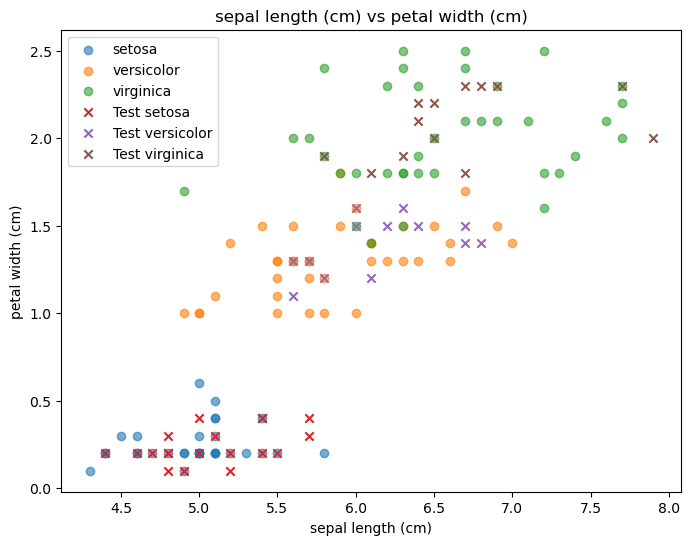

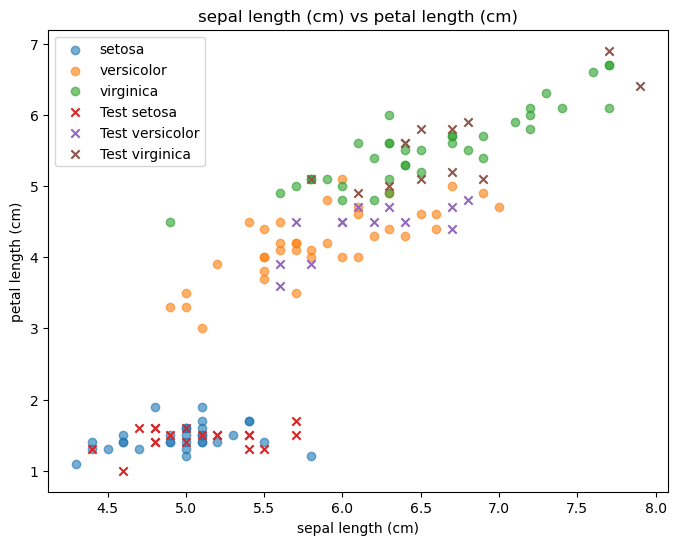

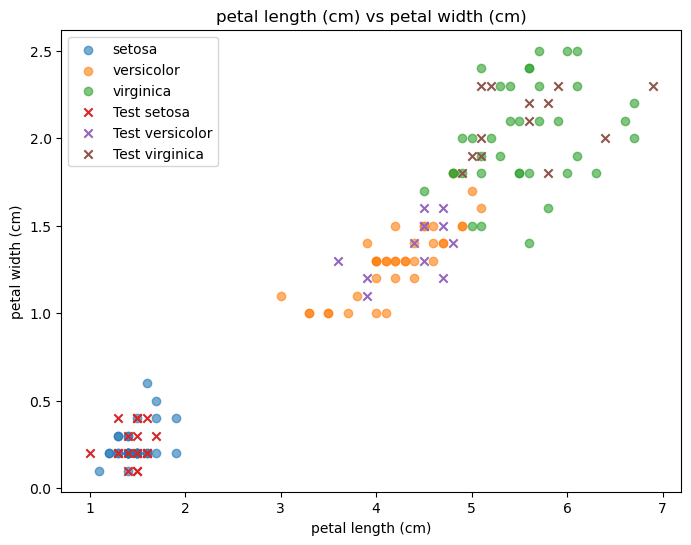

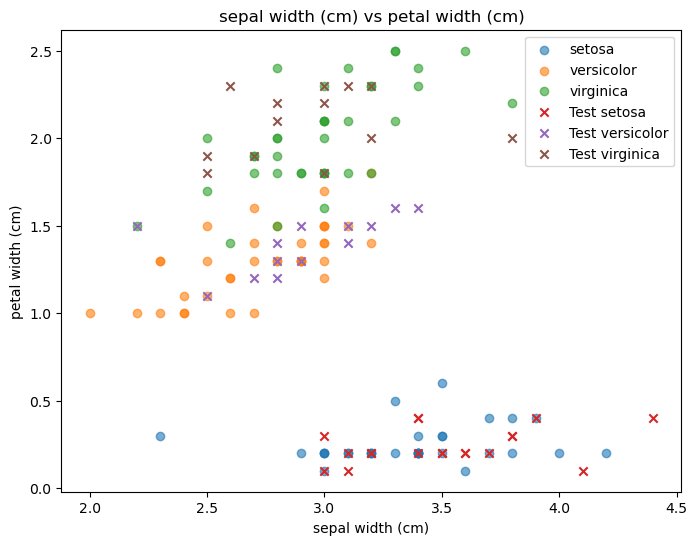

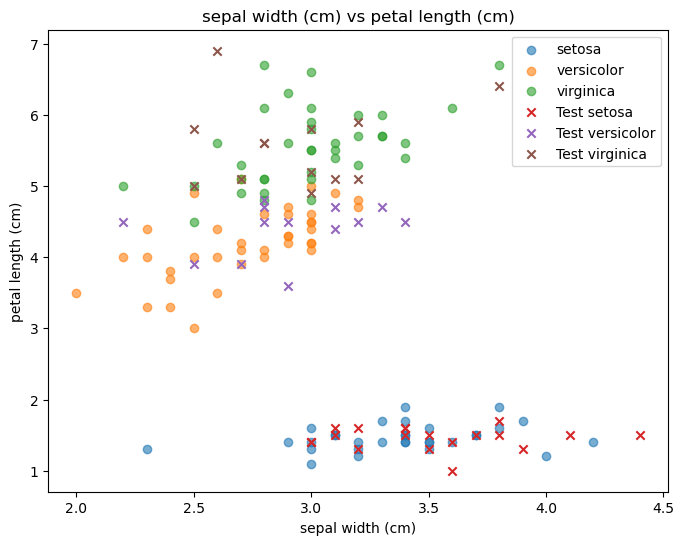

In [5]:
feature_pairs = [
        ('sepal length (cm)', 'petal width (cm)'),
        ('sepal length (cm)', 'petal length (cm)'),
        ('petal length (cm)', 'petal width (cm)'),
        ('sepal width (cm)', 'petal width (cm)'),
        ('sepal width (cm)', 'petal length (cm)')
    ]

for feature_x, feature_y in feature_pairs:
    plot_scatter(feature_x, feature_y, X_train, X_test, y_train, y_test, y_pred)

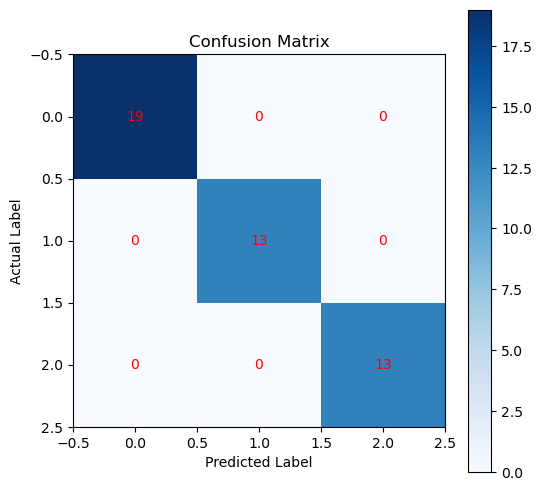

In [6]:
from sklearn.metrics import confusion_matrix,accuracy_score

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 6))
plt.imshow(conf_matrix, cmap='Blues', interpolation='none')
plt.title('Confusion Matrix')
plt.colorbar()
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

# Annotating the matrix with numbers
for i in range(len(conf_matrix)):
    for j in range(len(conf_matrix[i])):
        plt.text(j, i, conf_matrix[i, j], ha='center', va='center', color='red')

plt.show()

In [7]:
import ipywidgets as widgets
k_slider = widgets.IntSlider(value=3, min=1, max=20, description='K Value')
feature_x_dropdown = widgets.Dropdown(options=iris.feature_names, description='Feature X')
feature_y_dropdown = widgets.Dropdown(options=iris.feature_names, description='Feature Y')

def update_plot(k_value, feature_x, feature_y):
    # Step 6: Train KNN and Display Results
    X = df.drop('target', axis=1)
    y = df['target']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    knn = KNeighborsClassifier(n_neighbors=k_value)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    # Step 7: Calculate Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Accuracy for K={k_value}: {accuracy:.2f}')

    # Plot the updated scatter plot with training and test data
    plot_scatter(feature_x, feature_y, X_train, X_test, y_train, y_test, y_pred)

# Link the interactive widgets to the update function
widgets.interactive(update_plot, k_value=k_slider, feature_x=feature_x_dropdown, feature_y=feature_y_dropdown)

interactive(children=(IntSlider(value=3, description='K Value', max=20, min=1), Dropdown(description='Feature …

In [8]:
sepal_length = 9
sepal_width = 9
petal_length = 9
petal_width = 9
sample = pd.DataFrame({
    'sepal length (cm)': [sepal_length],
    'sepal width (cm)': [sepal_width],
    'petal length (cm)': [petal_length],
    'petal width (cm)': [petal_width]
})
print(f'Predicted species: {iris.target_names[knn.predict(sample)[0]]}')

Predicted species: virginica
